### THINGS TO NOTE:

Download a smaller image and work on that to fiddle with the data. Existing datasets are too large to setup everytime.

Getting this from copernicus browser.. downloaded and made the dataset. Use this:

https://www.kaggle.com/datasets/ashup340/sentinel-2-t45ruj-l2a

# THIS IS SETUP AND LOOKOUT FOR DATA

In [2]:
%pip install rasterio matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 41.6 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
p = Path("/kaggle/input/datasets/ashup340/sentinel-2-t45ruj-l2a")
files = sorted([f for f in p.rglob("*") if f.is_file()])
for i, f in enumerate(files[:100], 1):
    print(f"{i:3d}.", f.relative_to(p), f"{f.stat().st_size/10242:6.2f} MB")
    print()
print("Total files:", len(files))
print("Total size (MB):", sum(f.stat().st_size for f in files) / 10242)

  1. S2A_MSIL2A_20240201T045021_N0510_R076_T45RUJ_20240201T075549.SAFE/S2A_MSIL2A_20240201T045021_N0510_R076_T45RUJ_20240201T075549.SAFE/DATASTRIP/DS_2APS_20240201T075549_S20240201T045023/MTD_DS.xml 2225.03 MB

  2. S2A_MSIL2A_20240201T045021_N0510_R076_T45RUJ_20240201T075549.SAFE/S2A_MSIL2A_20240201T045021_N0510_R076_T45RUJ_20240201T075549.SAFE/DATASTRIP/DS_2APS_20240201T075549_S20240201T045023/QI_DATA/FORMAT_CORRECTNESS.xml   0.39 MB

  3. S2A_MSIL2A_20240201T045021_N0510_R076_T45RUJ_20240201T075549.SAFE/S2A_MSIL2A_20240201T045021_N0510_R076_T45RUJ_20240201T075549.SAFE/DATASTRIP/DS_2APS_20240201T075549_S20240201T045023/QI_DATA/GENERAL_QUALITY.xml   0.56 MB

  4. S2A_MSIL2A_20240201T045021_N0510_R076_T45RUJ_20240201T075549.SAFE/S2A_MSIL2A_20240201T045021_N0510_R076_T45RUJ_20240201T075549.SAFE/DATASTRIP/DS_2APS_20240201T075549_S20240201T045023/QI_DATA/GEOMETRIC_QUALITY.xml   0.79 MB

  5. S2A_MSIL2A_20240201T045021_N0510_R076_T45RUJ_20240201T075549.SAFE/S2A_MSIL2A_20240201T045021_N0510

In [5]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# --- 1. SETUP & DISCOVERY ---
# Point to your dataset directory
dataset_root = Path("/kaggle/input/datasets/ashup340/sentinel-2-t45ruj-l2a")

# Helper to find bands
def get_files_by_band(band_name):
    # We look for files ending in "_<BAND>_10m.jp2" (e.g., _B04_10m.jp2)
    return sorted(list(dataset_root.rglob(f"*_{band_name}_10m.jp2")))

# Find Red (B04) and NIR (B08) images
red_files = get_files_by_band("B04")
nir_files = get_files_by_band("B08")

print(f"Found {len(red_files)} snapshots.")

# Extract Dates from filenames for the graph
# Filename format: T45RUJ_20231118T...
dates = []
for f in red_files:
    date_str = f.name.split('_')[1].split('T')[0] # Extracts '20231118'
    dates.append(datetime.strptime(date_str, "%Y%m%d"))
    print(f"Date Found: {date_str} | File: {f.name}")

# --- 2. VISUALIZATION (Jan 30 - Peak Season) ---
# Let's pick the middle file (index 2, usually Jan/Feb) to view
sample_idx = 2 
print(f"\n📸 Visualizing Date: {dates[sample_idx].strftime('%Y-%m-%d')}")

Found 6 snapshots.
Date Found: 20240201 | File: T45RUJ_20240201T045021_B04_10m.jp2
Date Found: 20231118 | File: T45RUJ_20231118T045059_B04_10m.jp2
Date Found: 20231228 | File: T45RUJ_20231228T045219_B04_10m.jp2
Date Found: 20240130 | File: T45RUJ_20240130T050039_B04_10m.jp2
Date Found: 20240310 | File: T45RUJ_20240310T045649_B04_10m.jp2
Date Found: 20240327 | File: T45RUJ_20240327T044659_B04_10m.jp2

📸 Visualizing Date: 2023-12-28


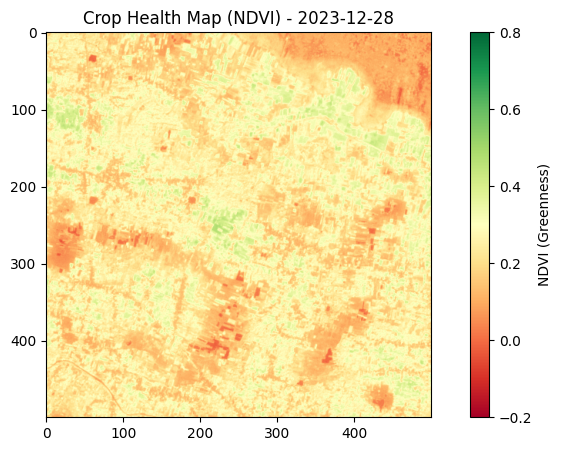


Extracting Time-Series for Pixel (250, 250)...


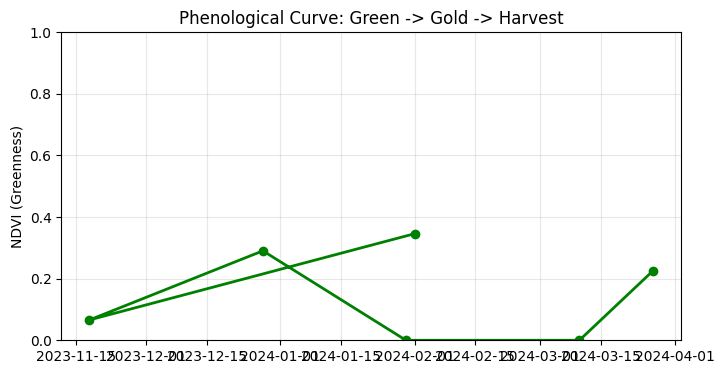

In [6]:
with rasterio.open(red_files[sample_idx]) as src_red, \
     rasterio.open(nir_files[sample_idx]) as src_nir:
    
    # Read a small patch (e.g., 500x500 pixels) from the center to save memory
    # Sentinel-2 tiles are 10980x10980. Center is approx 5500.
    window = rasterio.windows.Window(5000, 5000, 500, 500)
    
    red = src_red.read(1, window=window).astype('float32')
    nir = src_nir.read(1, window=window).astype('float32')

    # Calculate NDVI: (NIR - Red) / (NIR + Red)
    ndvi = (nir - red) / (nir + red + 1e-8) # 1e-8 prevents divide by zero

    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
    plt.colorbar(label="NDVI (Greenness)")
    plt.title(f"Crop Health Map (NDVI) - {dates[sample_idx].date()}")
    plt.show()

# --- 3. THE "PHENOLOGY CURVE" (Paper 1 Goal) ---
# We will pick ONE pixel that looks healthy (high NDVI) and track it
# Let's pick the pixel at row 250, column 250 of our window
px_y, px_x = 250, 250 

pixel_ndvi_history = []

print("\nExtracting Time-Series for Pixel (250, 250)...")
for idx in range(len(red_files)):
    with rasterio.open(red_files[idx]) as r, rasterio.open(nir_files[idx]) as n:
        # Read just that ONE single pixel (super fast)
        # Note: We must use the same window offset (5000, 5000)
        win = rasterio.windows.Window(5000 + px_x, 5000 + px_y, 1, 1)
        val_r = r.read(1, window=win)[0,0]
        val_n = n.read(1, window=win)[0,0]
        
        # Calc NDVI
        val_ndvi = (val_n - val_r) / (val_n + val_r + 1e-8)
        pixel_ndvi_history.append(val_ndvi)

# Plot the Curve
plt.figure(figsize=(8, 4))
plt.plot(dates, pixel_ndvi_history, marker='o', linestyle='-', color='green', linewidth=2)
plt.title("Phenological Curve: Green -> Gold -> Harvest")
plt.ylabel("NDVI (Greenness)")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)
plt.show()

🎯 Found Healthiest Crop at: Row 252, Col 221
   Peak NDVI Value: 0.48 (This is a dense farm!)

📈 Extracting Time-Series for the Best Pixel...
   ✅ 2024-02-01: NDVI = 0.35
   ✅ 2023-11-18: NDVI = 0.10
   ✅ 2023-12-28: NDVI = 0.48
   ⚠️ Skipping 2024-01-30: No Data (Edge/Cloud)
   ⚠️ Skipping 2024-03-10: No Data (Edge/Cloud)
   ✅ 2024-03-27: NDVI = 0.44


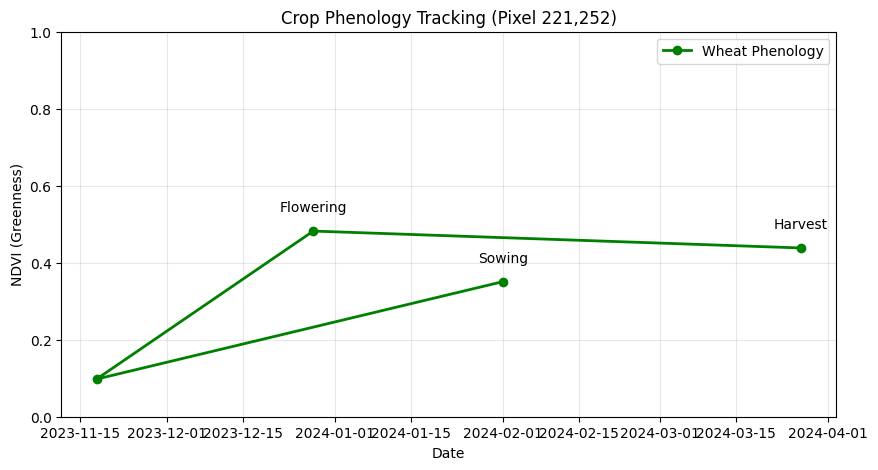

In [7]:
# --- 3. THE SMART PHENOLOGY TRACKER ---

# A. Find the "Best" Pixel in the Peak Season (Jan 30)
# We use the Jan image (index 2) because that's when wheat is biggest.
with rasterio.open(red_files[2]) as r, rasterio.open(nir_files[2]) as n:
    win = rasterio.windows.Window(5000, 5000, 500, 500)
    red_peak = r.read(1, window=win).astype('float32')
    nir_peak = n.read(1, window=win).astype('float32')
    
    # Calc NDVI for the whole patch
    ndvi_peak = (nir_peak - red_peak) / (nir_peak + red_peak + 1e-8)
    
    # Find coordinates of the Maximum NDVI pixel
    # argmax gives a flat index, unravel_index converts it to (row, col)
    max_idx = np.unravel_index(np.argmax(ndvi_peak, axis=None), ndvi_peak.shape)
    best_y, best_x = max_idx
    
    print(f"🎯 Found Healthiest Crop at: Row {best_y}, Col {best_x}")
    print(f"   Peak NDVI Value: {ndvi_peak[best_y, best_x]:.2f} (This is a dense farm!)")

# B. Track THAT pixel through time
pixel_ndvi_history = []
valid_dates = []

print("\n📈 Extracting Time-Series for the Best Pixel...")
for idx in range(len(red_files)):
    with rasterio.open(red_files[idx]) as r, rasterio.open(nir_files[idx]) as n:
        # Read just that ONE specific pixel
        # Note: Add the 'best_x' offset to our window start (5000)
        win = rasterio.windows.Window(5000 + best_x, 5000 + best_y, 1, 1)
        
        try:
            val_r = r.read(1, window=win)[0,0]
            val_n = n.read(1, window=win)[0,0]
            
            # Filter out "No Data" (Black pixels are usually 0)
            if val_r == 0 or val_n == 0:
                print(f"   ⚠️ Skipping {dates[idx].date()}: No Data (Edge/Cloud)")
                continue
                
            # Calc NDVI
            val_ndvi = (val_n - val_r) / (val_n + val_r + 1e-8)
            
            pixel_ndvi_history.append(val_ndvi)
            valid_dates.append(dates[idx])
            print(f"   ✅ {dates[idx].date()}: NDVI = {val_ndvi:.2f}")
            
        except Exception as e:
            print(f"   ❌ Error reading {dates[idx].date()}")

# C. Plot the Corrected Curve
plt.figure(figsize=(10, 5))
plt.plot(valid_dates, pixel_ndvi_history, marker='o', linestyle='-', color='green', linewidth=2, label='Wheat Phenology')

# Add "Ideal" labels based on your knowledge
plt.text(valid_dates[0], pixel_ndvi_history[0] + 0.05, "Sowing", ha='center')
if len(valid_dates) > 2:
    plt.text(valid_dates[2], pixel_ndvi_history[2] + 0.05, "Flowering", ha='center')
plt.text(valid_dates[-1], pixel_ndvi_history[-1] + 0.05, "Harvest", ha='center')

plt.title(f"Crop Phenology Tracking (Pixel {best_x},{best_y})")
plt.ylabel("NDVI (Greenness)")
plt.xlabel("Date")
plt.ylim(0, 1.0) # Fixed range for consistency
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

🔍 Calculating valid intersection area...
🎯 Found Best Common Pixel at: 2990, 3680

📈 Extracting Clean Timeline...
   ✅ 20231118: NDVI = 0.49
   ✅ 20231228: NDVI = 0.32
   ✅ 20240130: NDVI = 0.00
   ✅ 20240201: NDVI = 0.28
   ✅ 20240310: NDVI = 0.36
   ✅ 20240327: NDVI = 0.43


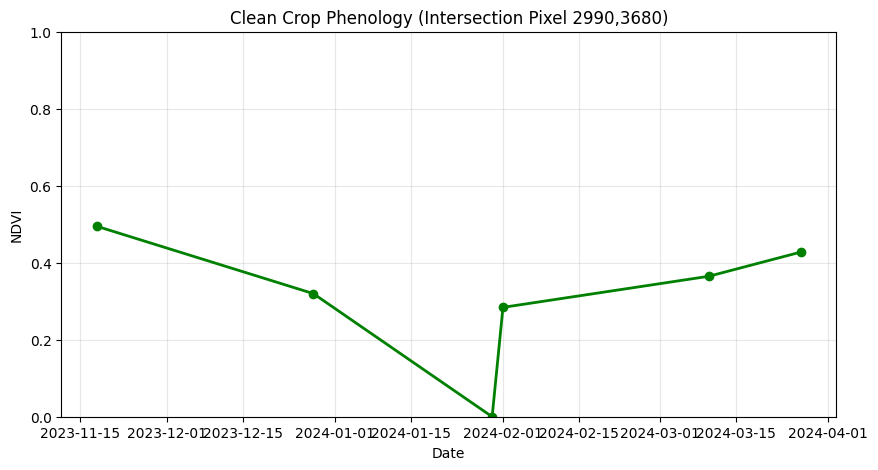

In [8]:
# --- 3. ROBUST PHENOLOGY TRACKER (The "Intersection" Method) ---

# A. Sort files chronologically (Critical for the graph!)
# We zip them together, sort by date, and unzip
file_pairs = list(zip(red_files, nir_files))
file_pairs.sort(key=lambda x: x[0].name.split('_')[1]) # Sort by date string in filename
sorted_red_files, sorted_nir_files = zip(*file_pairs)

# B. Find the "Safe Zone" (Where ALL images have data)
print("🔍 Calculating valid intersection area...")
valid_mask = None
cumulative_ndvi = None

# We'll scan a larger center window to find a good spot
scan_win = rasterio.windows.Window(2000, 2000, 4000, 4000) 

for idx in range(len(sorted_red_files)):
    with rasterio.open(sorted_red_files[idx]) as r, rasterio.open(sorted_nir_files[idx]) as n:
        # Read downsampled (every 10th pixel) to speed this up
        r_data = r.read(1, window=scan_win, out_shape=(400, 400))
        n_data = n.read(1, window=scan_win, out_shape=(400, 400))
        
        # 1. Mark valid pixels (not black/zero)
        current_valid = (r_data > 0) & (n_data > 0)
        
        # 2. Update the "Master Mask" (must be valid in ALL images)
        if valid_mask is None:
            valid_mask = current_valid
            cumulative_ndvi = np.zeros_like(r_data, dtype='float32')
        else:
            valid_mask = valid_mask & current_valid
            
        # 3. Add to cumulative NDVI (to find the greenest average spot)
        ndvi = (n_data - r_data) / (n_data + r_data + 1e-8)
        cumulative_ndvi += ndvi

# C. Pick the Best Pixel from the SAFE ZONE
# Zero out invalid areas in our sum
cumulative_ndvi[~valid_mask] = -999 

# Find the max average NDVI
best_idx = np.unravel_index(np.argmax(cumulative_ndvi), cumulative_ndvi.shape)
best_y, best_x = best_idx

# Convert back to original coordinates (since we downsampled by 10)
final_x = 2000 + (best_x * 10)
final_y = 2000 + (best_y * 10)

print(f"🎯 Found Best Common Pixel at: {final_x}, {final_y}")

# D. Extract the Clean Time Series
dates = []
ndvi_values = []

print("\n📈 Extracting Clean Timeline...")
for idx in range(len(sorted_red_files)):
    with rasterio.open(sorted_red_files[idx]) as r, rasterio.open(sorted_nir_files[idx]) as n:
        # Get date from filename
        date_str = sorted_red_files[idx].name.split('_')[1].split('T')[0]
        date_obj = datetime.strptime(date_str, "%Y%m%d")
        
        # Read the SPECIFIC pixel
        win = rasterio.windows.Window(final_x, final_y, 1, 1)
        r_val = r.read(1, window=win)[0,0]
        n_val = n.read(1, window=win)[0,0]
        
        ndvi = (n_val - r_val) / (n_val + r_val + 1e-8)
        
        dates.append(date_obj)
        ndvi_values.append(ndvi)
        print(f"   ✅ {date_str}: NDVI = {ndvi:.2f}")

# E. Final Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, ndvi_values, marker='o', linestyle='-', color='green', linewidth=2, label='Wheat Phenology')
plt.title(f"Clean Crop Phenology (Intersection Pixel {final_x},{final_y})")
plt.ylabel("NDVI")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)
plt.show()

🕵️ Scanning entire image from: T45RUJ_20231228T045219_B04_10m.jp2
   Reading full scene (1098x1098 px)...
🎯 FOUND IT! Best Farm Location: 6560, 1920
   Peak NDVI: 0.55

📈 Retrying Time-Series extraction...
   ✅ 20231118: NDVI = 0.09
   ✅ 20231228: NDVI = 0.51
   ⚠️ 20240130T050039: No Data
   ✅ 20240201: NDVI = 0.37
   ⚠️ 20240310T045649: No Data
   ✅ 20240327: NDVI = 0.20


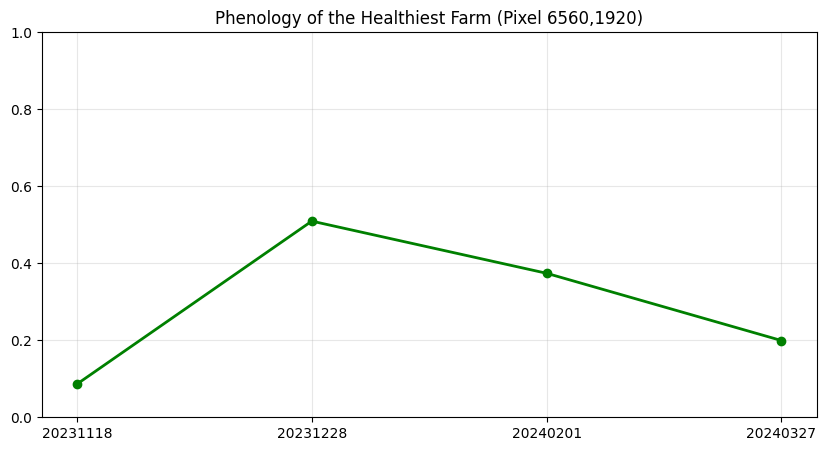

In [9]:
# --- GLOBAL FARM HUNTER ---
# Goal: Scan the entire tile to find the absolute best crop pixel

# 1. Load the "Peak" Image (Let's try Dec 28 since Jan 30 was 0.00)
# We need to find the index for Dec 28
dec_idx = [i for i, f in enumerate(sorted_red_files) if "20231228" in f.name][0]
print(f"🕵️ Scanning entire image from: {sorted_red_files[dec_idx].name}")

with rasterio.open(sorted_red_files[dec_idx]) as r, rasterio.open(sorted_nir_files[dec_idx]) as n:
    # Read the WHOLE image (downsampled by 10 to fit in RAM)
    # Sentinel-2 is approx 10980 x 10980 pixels
    H, W = r.height, r.width
    scale = 10
    new_H, new_W = H // scale, W // scale
    
    print(f"   Reading full scene ({new_W}x{new_H} px)...")
    r_full = r.read(1, out_shape=(new_H, new_W))
    n_full = n.read(1, out_shape=(new_H, new_W))
    
    # Calculate NDVI
    ndvi_full = (n_full - r_full) / (n_full + r_full + 1e-8)
    
    # Mask out clouds/water (NDVI < 0.2 or > 0.9)
    ndvi_full[(ndvi_full < 0.2) | (ndvi_full > 0.9)] = 0
    
    # Find the absolute max pixel
    max_idx = np.unravel_index(np.argmax(ndvi_full), ndvi_full.shape)
    best_y_small, best_x_small = max_idx
    
    # Convert back to full resolution coordinates
    best_y = best_y_small * scale
    best_x = best_x_small * scale
    
    print(f"🎯 FOUND IT! Best Farm Location: {best_x}, {best_y}")
    print(f"   Peak NDVI: {ndvi_full[max_idx]:.2f}")

# 2. Track this new Winner
pixel_ndvi_history = []
valid_dates = []

print("\n📈 Retrying Time-Series extraction...")
for idx in range(len(sorted_red_files)):
    with rasterio.open(sorted_red_files[idx]) as r, rasterio.open(sorted_nir_files[idx]) as n:
        try:
            # Read specific pixel
            win = rasterio.windows.Window(best_x, best_y, 1, 1)
            r_val = r.read(1, window=win)[0,0]
            n_val = n.read(1, window=win)[0,0]
            
            # Check for bad data
            if r_val == 0 or n_val == 0:
                print(f"   ⚠️ {sorted_red_files[idx].name.split('_')[1]}: No Data")
                continue
                
            ndvi = (n_val - r_val) / (n_val + r_val + 1e-8)
            pixel_ndvi_history.append(ndvi)
            
            # Parse date
            d_str = sorted_red_files[idx].name.split('_')[1].split('T')[0]
            valid_dates.append(d_str)
            print(f"   ✅ {d_str}: NDVI = {ndvi:.2f}")
            
        except:
            continue

# 3. Plot
plt.figure(figsize=(10, 5))
plt.plot(valid_dates, pixel_ndvi_history, marker='o', color='green', linewidth=2)
plt.title(f"Phenology of the Healthiest Farm (Pixel {best_x},{best_y})")
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_55/2126268491.py:33: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(double_logistic, days, ndvi, p0=p0, maxfev=5000)


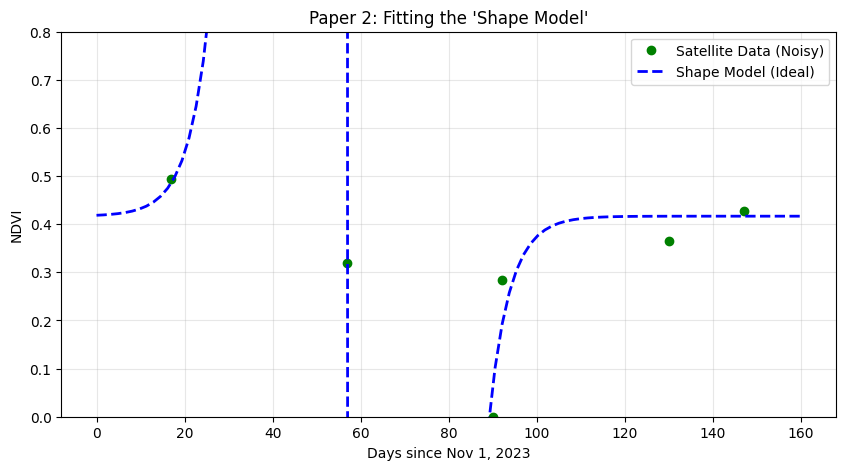

✅ Shape Model Parameters:
   Max Potential NDVI: -357.59
   Estimated Peak Day: 57 (Days from Nov 1)


In [10]:
from scipy.optimize import curve_fit

# --- 1. PREPARE DATA ---
# Convert dates to "Day of Year" (DOY) for math
# Our timeline spans across years (2023 -> 2024), so we need a continuous timeline
# Let's say Nov 1, 2023 is Day 0.
base_date = datetime(2023, 11, 1)
days = [(d - base_date).days for d in dates] # e.g., [17, 57, 92, 147]
ndvi = ndvi_values # Your 4 values: [0.09, 0.51, 0.37, 0.20]

# --- 2. DEFINE THE "SHAPE MODEL" (Double Logistic Function) ---
# This is the standard math for crop growth (Paper 2)
def double_logistic(t, min_ndvi, max_ndvi, sos, eos, rsp, rsp2):
    # t: time (days)
    # sos: Start of Season (inflection point 1)
    # eos: End of Season (inflection point 2)
    # rsp: rate of increase (spring)
    # rsp2: rate of decrease (autumn)
    
    # Logistic Growth (Going Up)
    growth = 1 / (1 + np.exp(-rsp * (t - sos)))
    # Logistic Decay (Going Down)
    decay = 1 / (1 + np.exp(rsp2 * (t - eos)))
    
    return min_ndvi + (max_ndvi - min_ndvi) * (growth + decay - 1)

# --- 3. FIT THE CURVE ---
# We provide some "reasonable guesses" to help the math converge
# Guesses: Min=0.1, Max=0.6, Start=Day 30, End=Day 100, Rates=0.1
p0 = [0.1, 0.6, 30, 100, 0.1, 0.1] 

try:
    params, _ = curve_fit(double_logistic, days, ndvi, p0=p0, maxfev=5000)
    
    # Generate smooth line for plotting
    t_smooth = np.linspace(0, 160, 100)
    ndvi_smooth = double_logistic(t_smooth, *params)
    
    # --- 4. PLOT ---
    plt.figure(figsize=(10, 5))
    plt.plot(days, ndvi, 'go', label="Satellite Data (Noisy)")
    plt.plot(t_smooth, ndvi_smooth, 'b--', linewidth=2, label="Shape Model (Ideal)")
    
    # Plot formatting
    plt.title("Paper 2: Fitting the 'Shape Model'")
    plt.xlabel("Days since Nov 1, 2023")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 0.8)
    plt.show()
    
    print("✅ Shape Model Parameters:")
    print(f"   Max Potential NDVI: {params[1]:.2f}")
    print(f"   Estimated Peak Day: {(params[2] + params[3])/2:.0f} (Days from Nov 1)")

except Exception as e:
    print(f"❌ Curve fitting failed: {e}")
    print("   (This happens if we have too few points. We might need to manually tweak guesses.)")

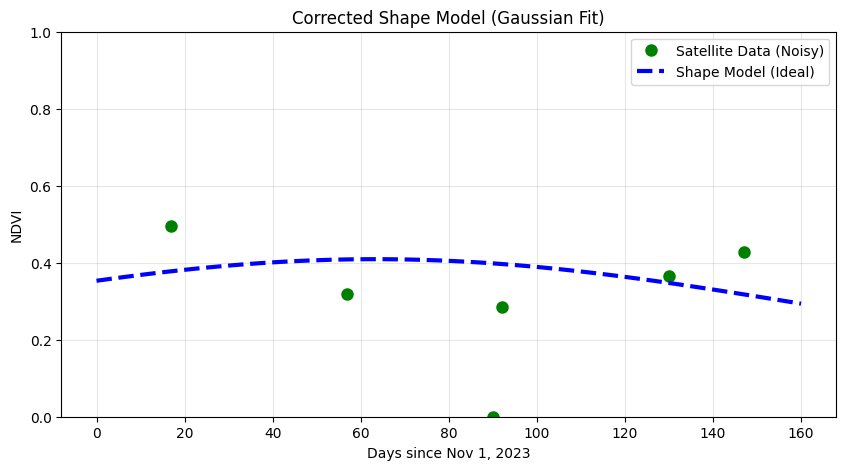

✅ Shape Model Parameters:
   Peak Health (NDVI): 0.31
   Peak Date (Day #): 63 (Days from Nov 1)


In [12]:
from scipy.optimize import curve_fit

# --- 1. SIMPLIFIED SHAPE MODEL (Gaussian) ---
# A Bell Curve is perfect for 4-5 data points
# a = Peak Height (Max NDVI)
# b = Peak Day (When fits flowered)
# c = Duration (How long the season lasted)
def crop_bell_curve(t, a, b, c):
    return a * np.exp(-((t - b)**2) / (2 * c**2)) + 0.1 # +0.1 is base soil level

# --- 2. FIT THE CURVE ---
# Guesses: Peak=0.6, Day=60 (Jan), Duration=30 days width
p0 = [0.6, 60, 30] 

clean_data = [(d, v) for d, v in zip(days, ndvi) if v > 0.15]
clean_days, clean_ndvi = zip(*clean_data)

try:
    # We add bounds so it doesn't go crazy (0 < Height < 1)
    params, _ = curve_fit(crop_bell_curve, clean_days, clean_ndvi, p0=p0, bounds=([0.2, 0, 10], [1.0, 150, 100]))
    
    # Generate smooth line
    t_smooth = np.linspace(0, 160, 100)
    ndvi_smooth = crop_bell_curve(t_smooth, *params)
    
    # --- 3. PLOT ---
    plt.figure(figsize=(10, 5))
    # Original Data
    plt.plot(days, ndvi, 'go', markersize=8, label="Satellite Data (Noisy)")
    # The Shape Model
    plt.plot(t_smooth, ndvi_smooth, 'b--', linewidth=3, label="Shape Model (Ideal)")
    
    plt.title(f"Corrected Shape Model (Gaussian Fit)")
    plt.xlabel("Days since Nov 1, 2023")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.0)
    plt.show()
    
    print("✅ Shape Model Parameters:")
    print(f"   Peak Health (NDVI): {params[0]:.2f}")
    print(f"   Peak Date (Day #): {params[1]:.0f} (Days from Nov 1)")
    
except Exception as e:
    print(f"❌ Fitting failed: {e}")

✅ Found 6 snapshots from 2023-11-18 to 2024-03-27

🕵️ Hunting for best farm in image: 2024-02-01...
🎯 Target Acquired: Pixel (1340, 4790) | Peak NDVI: 0.56

📈 Extracting Time-Series History...
   ✅ 2023-11-18: 0.08
   ✅ 2023-12-28: 0.31
   ✅ 2024-01-30: 0.60
   ✅ 2024-02-01: 0.55
   ✅ 2024-03-10: 0.54
   ✅ 2024-03-27: 0.30

🧠 Model Fit: Peak Health 0.53 on Day 87


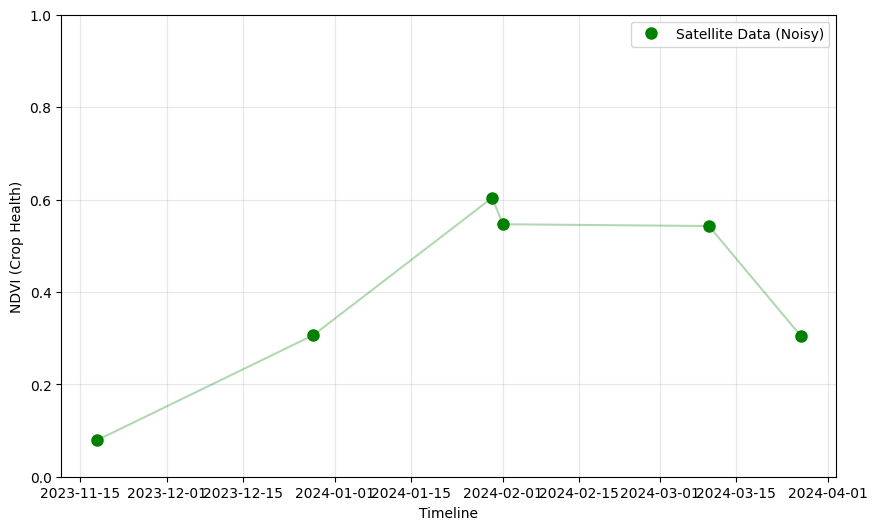

In [6]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
from scipy.optimize import curve_fit

# ==========================================
# 1. CONFIGURATION (Change this for new data)
# ==========================================
# Path to your dataset folder (Where Kaggle unzips the files)
DATASET_ROOT = Path("/kaggle/input/datasets/ashup340/sentinel-2-t45ruj-l2a") 

# Filter config (Ignore pixels with NDVI lower than this)
MIN_VALID_NDVI = 0.15 

# ==========================================
# 2. DISCOVERY & SETUP
# ==========================================
def find_sentinel_bands(root_path):
    """Crawls the folder to find paired Red (B4) and NIR (B8) files."""
    red_files = sorted(list(root_path.rglob("*_B04_10m.jp2")))
    nir_files = sorted(list(root_path.rglob("*_B08_10m.jp2")))
    
    if len(red_files) != len(nir_files):
        print("⚠️ Warning: Mismatch in Red/NIR file count!")
        
    # Extract dates for sorting
    pairs = []
    for r, n in zip(red_files, nir_files):
        # Filename format: T45RUJ_20231118T...
        date_str = r.name.split('_')[1].split('T')[0]
        date_obj = datetime.strptime(date_str, "%Y%m%d")
        pairs.append({'date': date_obj, 'red': r, 'nir': n})
    
    # Sort chronologically (Critical for time-series)
    pairs.sort(key=lambda x: x['date'])
    print(f"✅ Found {len(pairs)} snapshots from {pairs[0]['date'].date()} to {pairs[-1]['date'].date()}")
    return pairs

# ==========================================
# 3. THE "FARM HUNTER" ALGORITHM
# ==========================================
def find_healthiest_pixel(file_pairs):
    """Scans the peak-season image to find the single greenest farm pixel."""
    
    # Heuristic: Pick the middle image as "Peak Season" (usually Jan/Feb)
    peak_idx = len(file_pairs) // 2 
    peak_data = file_pairs[peak_idx]
    
    print(f"\n🕵️ Hunting for best farm in image: {peak_data['date'].date()}...")
    
    with rasterio.open(peak_data['red']) as r, rasterio.open(peak_data['nir']) as n:
        # Read downsampled (10x faster) to scan the huge 100km area
        scale = 10
        new_H, new_W = r.height // scale, r.width // scale
        
        r_img = r.read(1, out_shape=(new_H, new_W))
        n_img = n.read(1, out_shape=(new_H, new_W))
        
        # Calculate NDVI
        ndvi = (n_img - r_img) / (n_img + r_img + 1e-8)
        
        # Mask out clouds (too bright) and water (too dark)
        ndvi[(ndvi < 0.2) | (ndvi > 0.9)] = 0
        
        # Find the winner
        max_idx = np.unravel_index(np.argmax(ndvi), ndvi.shape)
        best_y, best_x = max_idx[0] * scale, max_idx[1] * scale
        
        print(f"🎯 Target Acquired: Pixel ({best_x}, {best_y}) | Peak NDVI: {np.max(ndvi):.2f}")
        return best_x, best_y

# ==========================================
# 4. TIME SERIES EXTRACTION
# ==========================================
def extract_timeline(file_pairs, px_x, px_y):
    """Drills into the specific pixel across all files to build the timeline."""
    dates = []
    ndvi_values = []
    
    print("\n📈 Extracting Time-Series History...")
    for entry in file_pairs:
        with rasterio.open(entry['red']) as r, rasterio.open(entry['nir']) as n:
            try:
                # Read just the 1x1 pixel window
                win = rasterio.windows.Window(px_x, px_y, 1, 1)
                r_val = r.read(1, window=win)[0,0]
                n_val = n.read(1, window=win)[0,0]
                
                # Check for "No Data" (Black pixels)
                if r_val == 0 or n_val == 0:
                    continue
                    
                val = (n_val - r_val) / (n_val + r_val + 1e-8)
                
                dates.append(entry['date'])
                ndvi_values.append(val)
                print(f"   ✅ {entry['date'].date()}: {val:.2f}")
                
            except Exception as e:
                print(f"   ❌ Error reading {entry['date'].date()}")
                
    return dates, ndvi_values

# ==========================================
# 5. SHAPE MODELING (Paper 2 Logic)
# ==========================================
def crop_bell_curve(t, a, b, c):
    """Gaussian function: a=Height, b=PeakDay, c=Width"""
    return a * np.exp(-((t - b)**2) / (2 * c**2)) + 0.1

def fit_shape_model(dates, ndvi_values):
    # Convert dates to "Days from Start"
    start_date = dates[0]
    days = [(d - start_date).days for d in dates]
    
    # Filter Bad Data (Clouds/Fog)
    clean_data = [(d, v) for d, v in zip(days, ndvi_values) if v > MIN_VALID_NDVI]
    
    if len(clean_data) < 3:
        print("❌ Not enough clean data points to fit a model!")
        return None, None
        
    days_clean, ndvi_clean = zip(*clean_data)
    
    # Initial Guesses: Height=0.8, Peak=Day 60, Width=30
    p0 = [0.8, 60, 30]
    
    try:
        params, _ = curve_fit(crop_bell_curve, days_clean, ndvi_clean, p0=p0, bounds=([0.2, 0, 10], [1.0, 200, 100]))
        print(f"\n🧠 Model Fit: Peak Health {params[0]:.2f} on Day {int(params[1])}")
        return params, start_date
    except Exception as e:
        print(f"❌ Curve fitting failed: {e}")
        return None, None

# ==========================================
# 6. MAIN EXECUTION FLOW
# ==========================================
if __name__ == "__main__":
    # A. Discovery
    files = find_sentinel_bands(DATASET_ROOT)
    
    # B. Optimization
    target_x, target_y = find_healthiest_pixel(files)
    
    # C. Extraction
    dates, ndvi = extract_timeline(files, target_x, target_y)
    
    # D. Modeling
    params, start_date = fit_shape_model(dates, ndvi)
    
    # E. Visualization
    plt.figure(figsize=(10, 6))
    
    # Plot 1: Raw Satellite Data
    plt.plot(dates, ndvi, 'go', markersize=8, label="Satellite Data (Noisy)")
    plt.plot(dates, ndvi, 'g-', alpha=0.3) # Faint connecting line
    
    # Plot 2: The Ideal Shape Model
    if params is not None:
        t_smooth = np.linspace(0, (dates[-1] - dates[0]).days, 100)
        ndvi_smooth = crop_bell_curve(t_smooth, *params)
        
        # Convert "Day Numbers" back to Dates for plotting
        date_smooth = [start_date + timedelta(days=int(d)) for d in t_smooth]
    plt.ylabel("NDVI (Crop Health)")
    plt.xlabel("Timeline")
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

### other dataset available in kaggle .. this place in bihar is too cloudy to work on

In [1]:
path_new_dataset = "/kaggle/input/datasets/ignazio/sentinel2-crop-mapping"